# Pipeline 1: Collecting and preparing the dataset


In [2]:
try:
  import kaggle
except:
  !pip install kaggle
  import kaggle

In [3]:
import os
import json
with open(os.path.expanduser("../Ch6/kaggle.json"), "r") as f:
    kaggle_credentials = json.load(f)

kaggle_username = kaggle_credentials["username"]
kaggle_key = kaggle_credentials["key"]

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_key

In [4]:
kaggle.api.authenticate()

In [5]:
!kaggle datasets download -d radheshyamkollipara/bank-customer-churn

Dataset URL: https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn
License(s): other




  0%|          | 0.00/307k [00:00<?, ?B/s]
100%|██████████| 307k/307k [00:00<00:00, 125MB/s]


In [7]:
import zipfile

with zipfile.ZipFile('../Ch6/bank-customer-churn.zip', 'r') as zip_ref:
    zip_ref.extractall('../Ch6/')

print("File Unzipped!")

File Unzipped!


In [12]:
import pandas as pd

file_path = '../Ch6/Customer-Churn-Records.csv'
data1 = pd.read_csv(file_path)

data1.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


We will now drop the following columns:
- RowNumber: we will create a unique index for each record
- Surname: anonymize teh data
- Gender: more ethical
- Geography: avoid overfitting outputs based on cultural cliches.

In [13]:
data1.drop(columns=['RowNumber', 'Surname', 'Gender', 'Geography'], inplace=True)
data1.head()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [14]:
data1.to_csv('data1.csv', index=False)

### Exploratory Data Analysis (EDA)

In [15]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          10000 non-null  int64  
 1   CreditScore         10000 non-null  int64  
 2   Age                 10000 non-null  int64  
 3   Tenure              10000 non-null  int64  
 4   Balance             10000 non-null  float64
 5   NumOfProducts       10000 non-null  int64  
 6   HasCrCard           10000 non-null  int64  
 7   IsActiveMember      10000 non-null  int64  
 8   EstimatedSalary     10000 non-null  float64
 9   Exited              10000 non-null  int64  
 10  Complain            10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Card Type           10000 non-null  object 
 13  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(11), object(1)
memory usage: 1.1+ MB


In [16]:
data1

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


Our first analysis shows a direct correlation between customer complaints and churn rates, indicating that customers who have lodged complaints are more likely to leave the bank. Additionally, our data reveals that customers aged 50 and above are less liekly to churn compared to younger costumers. Income levels do not appear to influence churn decisions.

In [17]:
sum_exited = ((data1['Exited'] == 1).sum())
sum_complain = ((data1['Complain'] == 1).sum())

if sum_exited > 0:
    percentage_complain_over_exited = (sum_complain / sum_exited) * 100
else:
    percentage_complain_over_exited = 0

print(f"Total number of customers who exited: {sum_exited}")
print(f"Total number of customers who complained: {sum_complain}")

print(f"Percentage of customers who complained among those who exited: {percentage_complain_over_exited:.2f}%") 

Total number of customers who exited: 2038
Total number of customers who complained: 2044
Percentage of customers who complained among those who exited: 100.29%


The output shoes a very high ratio.

In [18]:
age = 50

In [19]:
# Calculate the sum of customers aged 50 and over who have also exited
sum_age_and_over_among_exited = data1[(data1['Age'] >= age) & (data1['Exited'] == 1)].shape[0]

# Calculate the sum of customers who have exited
sum_exited = (data1['Exited'] == 1).sum()

# Calculate the percentage of customers aged 50 and over among those who have exited
if sum_exited > 0:  # To avoid division by zero
    percentage_age_and_over_among_exited = (sum_age_and_over_among_exited / sum_exited) * 100
else:
    percentage_age_and_over_among_exited = 0

# Print results
print(f"Sum of Age {age} and Over among Exited = {sum_age_and_over_among_exited}")
print(f"Sum of Exited = {sum_exited}")
print(f"Percentage of Age {age} and Over among Exited = {percentage_age_and_over_among_exited:.2f}%")

Sum of Age 50 and Over among Exited = 634
Sum of Exited = 2038
Percentage of Age 50 and Over among Exited = 31.11%


The output shows that younger costumers seem more likely to leave a bank if tehy are not satisfied.

In [20]:
salary_threshold=100000

In [21]:
# Calculate the sum of customers with an estimated salary over the specified threshold who have also exited
sum_salary_over_among_exited = data1[(data1['EstimatedSalary'] >= salary_threshold) & (data1['Exited'] == 1)].shape[0]

# Calculate the sum of customers who have exited
sum_exited = (data1['Exited'] == 1).sum()

# Calculate the percentage of customers with a salary over the threshold among those who have exited
if sum_exited > 0:  # To avoid division by zero
    percentage_salary_over_among_exited = (sum_salary_over_among_exited / sum_exited) * 100
else:
    percentage_salary_over_among_exited = 0

# Print results
print(f"Sum of Estimated Salary over {salary_threshold} among Exited = {sum_salary_over_among_exited}")
print(f"Sum of Exited = {sum_exited}")
print(f"Percentage of Estimated Salary over {salary_threshold} among Exited = {percentage_salary_over_among_exited:.2f}%")

Sum of Estimated Salary over 100000 among Exited = 1045
Sum of Exited = 2038
Percentage of Estimated Salary over 100000 among Exited = 51.28%


This relation doesn't seem to be so significant.

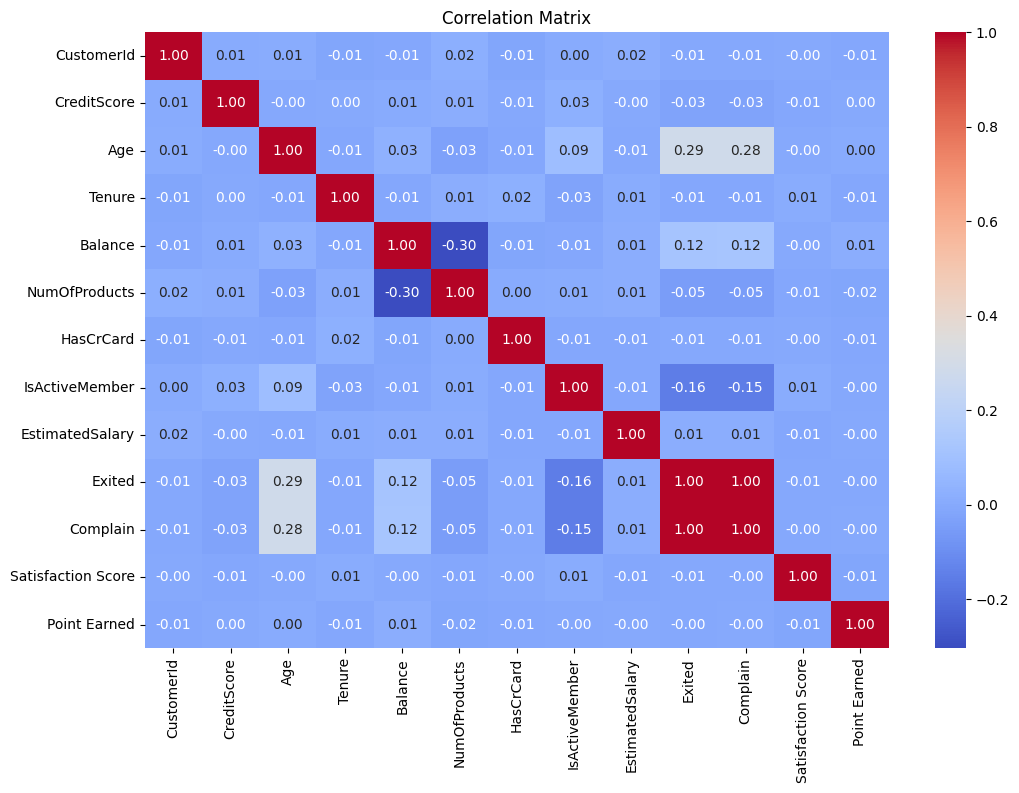

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = data1.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))
sns.heatmap(data1[numerical_columns].corr(), annot=True, cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


### Training a ML Model

In [23]:
data2 = data1.copy()

In [24]:
import pandas as pd 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = data2[['CreditScore', 'Age', 'EstimatedSalary', 'Exited', 'Complain', 'Point Earned']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [25]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

for n_clusters in range(2, 5):
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=0)
    cluster_labels = kmeans.fit_predict(scaled_features)
    
    silhouette_avg = silhouette_score(scaled_features, cluster_labels)
    davies_bouldin_avg = davies_bouldin_score(scaled_features, cluster_labels)
    
    print(f"Number of Clusters: {n_clusters}")
    print(f"Silhouette Score: {silhouette_avg:.4f}")
    print(f"Davies-Bouldin Score: {davies_bouldin_avg:.4f}\n")

Number of Clusters: 2
Silhouette Score: 0.6129
Davies-Bouldin Score: 0.6144

Number of Clusters: 3
Silhouette Score: 0.3391
Davies-Bouldin Score: 1.1511

Number of Clusters: 4
Silhouette Score: 0.3243
Davies-Bouldin Score: 1.0801



The **silhoutte score** measures the quality of clustering by calcultaing the mean intra-cluster distance (how close each point in one cluster is to points in the same cluster) and the mean nearest cluster distance (how close each point isd to points in the next nearest cluster). The score ranges from -1 to 1, where a high value indicates taht clusters are well-separated andinternally cohesive.

The **Davies-Bouldin index** evaluates clustering quality by compairtng teh ratio of within-cluster distances to between-cluster distances. Lower values of this index indicate better clustering.

In [26]:
kmeans = KMeans(n_clusters=2, n_init=20, random_state=0)
data2['class'] = kmeans.fit_predict(scaled_features)

In [27]:
data2

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned,class
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464,1
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456,1
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377,1
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350,0
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300,0
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771,0
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564,1
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339,1


In [28]:
# 1. Sum where 'class' == 0
sum_class_0 = (data2['class'] == 0).sum()
# 2. Sum where 'class' == 0 and 'Complain' == 1
sum_class_0_complain_1 = data2[(data2['class'] == 0) & (data2['Complain'] == 1)].shape[0]
# 3. Sum where 'class' == 0 and 'Exited' == 1
sum_class_0_exited_1 = data2[(data2['class'] == 0) & (data2['Exited'] == 1)].shape[0]

# Print the results
print(f"Sum of 'class' == 0: {sum_class_0}")
print(f"Sum of 'class' == 0 and 'Complain' == 1: {sum_class_0_complain_1}")
print(f"Sum of 'class' == 0 and 'Exited' == 1: {sum_class_0_exited_1}")

Sum of 'class' == 0: 7961
Sum of 'class' == 0 and 'Complain' == 1: 8
Sum of 'class' == 0 and 'Exited' == 1: 1


In [29]:
# 1. Sum where 'class' == 1
sum_class_1 = (data2['class'] == 1).sum()

# 2. Sum where 'class' == 1 and 'Complain' == 1
sum_class_1_complain_1 = data2[(data2['class'] == 1) & (data2['Complain'] == 1)].shape[0]

# 3. Sum where 'class' == 1 and 'Exited' == 1
sum_class_1_exited_1 = data2[(data2['class'] == 1) & (data2['Exited'] == 1)].shape[0]

# Print the results
print(f"Sum of 'class' == 1: {sum_class_1}")
print(f"Sum of 'class' == 1 and 'Complain' == 1: {sum_class_1_complain_1}")
print(f"Sum of 'class' == 1 and 'Exited' == 1: {sum_class_1_exited_1}")

Sum of 'class' == 1: 2039
Sum of 'class' == 1 and 'Complain' == 1: 2036
Sum of 'class' == 1 and 'Exited' == 1: 2037


# Pipelines 2: Scaling the Pinecone vector store

In [44]:
!pip uninstall -y pinecone pinecone-client
!pip install pinecone-client==3.0.3
!pip cache purge

Found existing installation: pinecone 8.1.2
Uninstalling pinecone-8.1.2:
  Successfully uninstalled pinecone-8.1.2


Files removed: 2228 (854.6 MB)
Directories removed: 33


In [51]:
import os 
from pinecone import Pinecone, ServerlessSpec

# Get API key from environment
api_key = os.getenv("PINECONE_API_KEY")

if not api_key:
    raise ValueError("PINECONE_API_KEY not found in environment variables. Please set it in your .env file")

# Initialize Pinecone client
pc = Pinecone(api_key=api_key)

print("Pinecone initialized successfully!")
print(f"Available indexes: {pc.list_indexes()}")

Pinecone initialized successfully!
Available indexes: {'indexes': [{'dimension': 1024,
              'host': 'index-pgu82e5.svc.aped-4627-b74a.pinecone.io',
              'metric': 'cosine',
              'name': 'index',
              'spec': {'serverless': {'cloud': 'aws', 'region': 'us-east-1'}},
              'status': {'ready': True, 'state': 'Ready'}}]}


In [52]:
file_path = '../Ch6/data1.csv'
data1 = pd.read_csv(file_path)
data1

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,15634602,619,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,15647311,608,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,15619304,502,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,15701354,699,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,15737888,850,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,15569892,516,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,15584532,709,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,15682355,772,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


In [53]:
number_of_lines = len(data1)
number_of_lines

10000

In [54]:
import pandas as pd

output_lines = []
for index, row in data1.iterrows():
    row_data = [f"{col}: {row[col]}" for col in data1.columns]
    line = " ".join(row_data)
    output_lines.append(line)

for line in output_lines[:5]:  # Print the first 5 lines as a sample
    print(line)

CustomerId: 15634602 CreditScore: 619 Age: 42 Tenure: 2 Balance: 0.0 NumOfProducts: 1 HasCrCard: 1 IsActiveMember: 1 EstimatedSalary: 101348.88 Exited: 1 Complain: 1 Satisfaction Score: 2 Card Type: DIAMOND Point Earned: 464
CustomerId: 15647311 CreditScore: 608 Age: 41 Tenure: 1 Balance: 83807.86 NumOfProducts: 1 HasCrCard: 0 IsActiveMember: 1 EstimatedSalary: 112542.58 Exited: 0 Complain: 1 Satisfaction Score: 3 Card Type: DIAMOND Point Earned: 456
CustomerId: 15619304 CreditScore: 502 Age: 42 Tenure: 8 Balance: 159660.8 NumOfProducts: 3 HasCrCard: 1 IsActiveMember: 0 EstimatedSalary: 113931.57 Exited: 1 Complain: 1 Satisfaction Score: 3 Card Type: DIAMOND Point Earned: 377
CustomerId: 15701354 CreditScore: 699 Age: 39 Tenure: 1 Balance: 0.0 NumOfProducts: 2 HasCrCard: 0 IsActiveMember: 0 EstimatedSalary: 93826.63 Exited: 0 Complain: 0 Satisfaction Score: 5 Card Type: GOLD Point Earned: 350
CustomerId: 15737888 CreditScore: 850 Age: 43 Tenure: 2 Balance: 125510.82 NumOfProducts: 1 Ha

In [55]:
lines = output_lines.copy()
number_of_lines = len(lines)
print(f"Total number of lines: {number_of_lines}")

Total number of lines: 10000


### Chunking and embedding the dataset

In [56]:
import time

start_time = time.time()
chunks = []

for line in lines:
    chunks.append(line)
    
print("Total number of chunks created: ", len(chunks))
response_time = time.time() - start_time
print(f"Time taken to create chunks: {response_time:.4f} seconds")

Total number of chunks created:  10000
Time taken to create chunks: 0.0014 seconds


In [57]:
for i in range(3):
    print(f"Chunk {i+1}: {chunks[i]}")
    print(len(chunks[i]))

Chunk 1: CustomerId: 15634602 CreditScore: 619 Age: 42 Tenure: 2 Balance: 0.0 NumOfProducts: 1 HasCrCard: 1 IsActiveMember: 1 EstimatedSalary: 101348.88 Exited: 1 Complain: 1 Satisfaction Score: 2 Card Type: DIAMOND Point Earned: 464
224
Chunk 2: CustomerId: 15647311 CreditScore: 608 Age: 41 Tenure: 1 Balance: 83807.86 NumOfProducts: 1 HasCrCard: 0 IsActiveMember: 1 EstimatedSalary: 112542.58 Exited: 0 Complain: 1 Satisfaction Score: 3 Card Type: DIAMOND Point Earned: 456
229
Chunk 3: CustomerId: 15619304 CreditScore: 502 Age: 42 Tenure: 8 Balance: 159660.8 NumOfProducts: 3 HasCrCard: 1 IsActiveMember: 0 EstimatedSalary: 113931.57 Exited: 1 Complain: 1 Satisfaction Score: 3 Card Type: DIAMOND Point Earned: 377
229


In [62]:
import time 
from sentence_transformers import SentenceTransformer

start_time = time.time()
embedding_model = "all-MiniLM-L6-v2"
model = SentenceTransformer(embedding_model)
embeddings = model.encode(chunks, show_progress_bar=True)
response_time = time.time() - start_time
print(f"Time taken to create embeddings: {response_time:.4f} seconds")

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Time taken to create embeddings: 11.9130 seconds


In [63]:
print("First embedding:", embeddings[0])

First embedding: [-5.07081561e-02  1.31267484e-03 -7.29609057e-02  2.75141932e-02
 -1.60269942e-02  9.07163173e-02  3.95942945e-03  2.86507197e-02
 -4.50839214e-02 -4.57368158e-02 -2.20946353e-02 -1.68979406e-01
 -1.33398101e-02 -3.37747149e-02 -7.90682882e-02  2.44859676e-03
  5.50179780e-02 -3.27781737e-02  2.48470511e-02 -3.00632399e-02
 -3.29523534e-02  5.77356890e-02 -1.95399690e-02  1.27048567e-02
 -3.72169353e-02 -9.94176883e-03 -6.87087029e-02  5.54795153e-02
 -6.98276982e-02 -4.60800789e-02  6.05015084e-02  8.41370076e-02
  1.63047969e-01  3.94851752e-02  5.00938892e-02  2.08123215e-02
 -1.99424177e-02  1.71338841e-02 -5.50853685e-02 -4.92925905e-02
  1.01079559e-03 -3.37616131e-02 -1.66438837e-02  2.76917126e-02
  4.95367311e-02 -2.26323456e-02 -6.37981594e-02 -2.90326867e-02
  1.21928165e-02  1.01072922e-01 -5.53158149e-02  4.82528023e-02
 -1.22739375e-03 -4.65440117e-02 -3.74825560e-02  5.09901084e-02
  5.41966408e-04 -3.67508493e-02 -5.67188021e-03  2.25517210e-02
  3.2046

In [64]:
# Check the lengths of the chunks and embeddings
num_chunks = len(chunks)
print(f"Number of chunks: {num_chunks}")
print(f"Number of embeddings: {len(embeddings)}")

Number of chunks: 10000
Number of embeddings: 10000


In [65]:
# Define the duplication size
dsize = 5  # You can set this to any value between 1 and n as per your experimentation requirements
total=dsize * len(chunks)
print("Total size", total)
# Initialize new lists for duplicated chunks and embeddings
duplicated_chunks = []
duplicated_embeddings = []

# Loop through the original lists and duplicate each entry
for i in range(len(chunks)):
    for _ in range(dsize):
        duplicated_chunks.append(chunks[i])
        duplicated_embeddings.append(embeddings[i])

# Checking the lengths of the duplicated lists
print(f"Number of duplicated chunks: {len(duplicated_chunks)}")
print(f"Number of duplicated embeddings: {len(duplicated_embeddings)}")

Total size 50000
Number of duplicated chunks: 50000
Number of duplicated embeddings: 50000


### Pinecone index

In [67]:
import os
from pinecone import Pinecone, ServerlessSpec

api_key = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key)

In [68]:
index_name = 'index'
cloud = 'aws'
region = 'us-east-1'
spec = ServerlessSpec(cloud=cloud, region=region)

In [89]:
import time
import pinecone

# Get list of existing indexes
existing_indexes = pc.list_indexes()
index_names = [idx.name for idx in existing_indexes.indexes] if existing_indexes.indexes else []

print(f"Existing indexes: {index_names}")

# Delete existing index if it has wrong dimension
if index_name in index_names:
    print(f"Deleting existing '{index_name}' index to recreate with correct dimension...")
    pc.delete_index(index_name)
    time.sleep(2)
    print("Index deleted.")

# Create index with correct dimension (384 for all-MiniLM-L6-v2)
print(f"Creating index '{index_name}' with dimension 384...")
pc.create_index(name=index_name, dimension=384, metric='cosine', spec=spec)
time.sleep(2)
print("Index created successfully!")

# Connect to the index
index = pc.Index(index_name)
print("Connected to index.")
print(index.describe_index_stats())


Existing indexes: ['index']
Deleting existing 'index' index to recreate with correct dimension...
Index deleted.
Creating index 'index' with dimension 384...
Index created successfully!
Connected to index.
{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {},
 'total_vector_count': 0}


We added the follwoing two paramters:
- dimension: represents the length of the embeddings vector taht you can adapt to the embedding model of your choice.
- metric: we will use it for vector similarity between the embedded vectors.

### Upserting


We will populate teh vecxtor store with our 50000 embedded vectors and their associated metadata (chunks). We will populate it with three fields:
- ids: contains a unique identifier for each chunk, which will be a counter we increment as we upsert data.
- embeddings: contains the vectors we created
- chunks: contains the chunks in plain text, which is the metadata.

In [90]:
def upsert_to_pinecone(data, batch_size):
    """Upsert vectors to Pinecone"""
    for i in range(0, len(data), batch_size):
        batch = data[i:i+batch_size]
        try:
            index.upsert(vectors=batch)
            time.sleep(0.5)  # Reduced sleep time for faster upsert
        except Exception as e:
            print(f"Error upserting batch {i//batch_size + 1}: {e}")
            raise

In [91]:
import time
import sys
start_time = time.time()

def batch_upsert(data, max_batch_size=1000):
    """Upsert data in batches respecting Pinecone's 1000 vector limit"""
    total = len(data)
    i = 0
    batch_num = 1
    
    while i < total:
        # Use a fixed batch size, capped at Pinecone's max of 1000
        batch_size = min(max_batch_size, total - i)
        batch = data[i:i + batch_size]
        
        try:
            index.upsert(vectors=batch)
            i += batch_size
            print(f"Batch {batch_num} complete ({batch_size} vectors): Upserted {i}/{total} items...")
            batch_num += 1
            time.sleep(0.5)  # Small delay between batches
        except Exception as e:
            print(f"Error in batch {batch_num}: {e}")
            raise
    
    print("Upsert process complete!")

# Generate IDs and prepare data
print("Preparing data for upsert...")
ids = [str(i) for i in range(1, len(duplicated_chunks) + 1)]

# Convert embeddings to lists and prepare data
data_for_upsert = [
    {
        "id": str(id), 
        "values": emb.tolist() if hasattr(emb, 'tolist') else emb,  # Convert numpy array to list
        "metadata": {"text": chunk}
    } 
    for id, (chunk, emb) in zip(ids, zip(duplicated_chunks, duplicated_embeddings))
]

print(f"Total items to upsert: {len(data_for_upsert)}")
print(f"Sample data: ID={data_for_upsert[0]['id']}, Vector length={len(data_for_upsert[0]['values'])}")
print(f"Batch size: 1000 vectors per request (Pinecone max)\n")

# Perform upsert
batch_upsert(data_for_upsert, max_batch_size=1000)

response_time = time.time() - start_time
print(f"\nTotal time taken to upsert data: {response_time:.2f} seconds")

# Check final index stats
index_stats = index.describe_index_stats()
print(f"\nFinal index stats:")
print(f"Total vectors: {index_stats.get('total_vector_count', 'N/A')}")
print(f"Index dimension: {index_stats.get('dimension', 'N/A')}")


Preparing data for upsert...
Total items to upsert: 50000
Sample data: ID=1, Vector length=384
Batch size: 1000 vectors per request (Pinecone max)

Batch 1 complete (1000 vectors): Upserted 1000/50000 items...
Batch 2 complete (1000 vectors): Upserted 2000/50000 items...
Batch 3 complete (1000 vectors): Upserted 3000/50000 items...
Batch 4 complete (1000 vectors): Upserted 4000/50000 items...
Batch 5 complete (1000 vectors): Upserted 5000/50000 items...
Batch 6 complete (1000 vectors): Upserted 6000/50000 items...
Batch 7 complete (1000 vectors): Upserted 7000/50000 items...
Batch 8 complete (1000 vectors): Upserted 8000/50000 items...
Batch 9 complete (1000 vectors): Upserted 9000/50000 items...
Batch 10 complete (1000 vectors): Upserted 10000/50000 items...
Batch 11 complete (1000 vectors): Upserted 11000/50000 items...
Batch 12 complete (1000 vectors): Upserted 12000/50000 items...
Batch 13 complete (1000 vectors): Upserted 13000/50000 items...
Batch 14 complete (1000 vectors): Upse

In [92]:
print("Index stats")
print(index.describe_index_stats(include_metadata=True))

Index stats
{'dimension': 384,
 'index_fullness': 0.0,
 'namespaces': {'': {'vector_count': 50000}},
 'total_vector_count': 50000}


### Querying the index

In [93]:
# Print the query results along with metadata
def display_results(query_results):
  for match in query_results['matches']:
    print(f"ID: {match['id']}, Score: {match['score']}")
    if 'metadata' in match and 'text' in match['metadata']:
        print(f"Text: {match['metadata']['text']}")
    else:
        print("No metadata available.")

In [94]:
print("Performing a sample query...")
query_text = "Customer Robertson CreditScore 632Age 21 Tenure 2Balance 0.0NumOfProducts 1HasCrCard 1IsActiveMember 1EstimatedSalary 99000 Exited 1Complain 1Satisfaction Score 2Card Type DIAMONDPoint Earned 399"

Performing a sample query...


In [95]:
import time 
from sentence_transformers import SentenceTransformer

start_time = time.time()
embedding_model = "all-MiniLM-L6-v2"
model = SentenceTransformer(embedding_model)
query_embeddings = model.encode(query_text, show_progress_bar=True)
# Convert numpy array to list for Pinecone query
query_embeddings_list = query_embeddings.tolist() if hasattr(query_embeddings, 'tolist') else query_embeddings
query_results = index.query(vector=query_embeddings_list, top_k=1, include_metadata=True)

print("Query results:")
display_results(query_results)
response_time = time.time() - start_time
print(f"Time taken to create embeddings and query: {response_time:.4f} seconds")


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Query results:
ID: 3895, Score: 0.824712753
Text: CustomerId: 15797227 CreditScore: 754 Age: 28 Tenure: 8 Balance: 0.0 NumOfProducts: 2 HasCrCard: 1 IsActiveMember: 1 EstimatedSalary: 52615.62 Exited: 0 Complain: 0 Satisfaction Score: 4 Card Type: DIAMOND Point Earned: 497
Time taken to create embeddings and query: 4.3031 seconds


# Pipeline 3: A RAG Pinecone vector store for Generative AI


### Extract relevant texts

In [96]:
relevant_texts = [match['metadata']['text'] for match in query_results['matches'] if 'metadata' in match and 'text' in match['metadata']]

# Join all items in the list into a single string separated by a specific delimiter (e.g., a newline or space)
combined_text = '\n'.join(relevant_texts)  # Using newline as a separator for readability
print(combined_text)

CustomerId: 15797227 CreditScore: 754 Age: 28 Tenure: 8 Balance: 0.0 NumOfProducts: 2 HasCrCard: 1 IsActiveMember: 1 EstimatedSalary: 52615.62 Exited: 0 Complain: 0 Satisfaction Score: 4 Card Type: DIAMOND Point Earned: 497


### Augmented prompt

In [97]:
# Combine texts into a single string, separated by new lines
combined_context = "\n".join(relevant_texts)
#prompt
query_prompt="I have this customer bank record with interesting information on age, credit score and more and similar customers. What could I suggest to keep them in my bank in an email with an url to get new advantages based on the fields for each Customer ID:"
itext=query_prompt+ query_text+combined_context
# Augmented input
print("Prompt for the Generative AI model:", itext)

Prompt for the Generative AI model: I have this customer bank record with interesting information on age, credit score and more and similar customers. What could I suggest to keep them in my bank in an email with an url to get new advantages based on the fields for each Customer ID:Customer Robertson CreditScore 632Age 21 Tenure 2Balance 0.0NumOfProducts 1HasCrCard 1IsActiveMember 1EstimatedSalary 99000 Exited 1Complain 1Satisfaction Score 2Card Type DIAMONDPoint Earned 399CustomerId: 15797227 CreditScore: 754 Age: 28 Tenure: 8 Balance: 0.0 NumOfProducts: 2 HasCrCard: 1 IsActiveMember: 1 EstimatedSalary: 52615.62 Exited: 0 Complain: 0 Satisfaction Score: 4 Card Type: DIAMOND Point Earned: 497


### Augmented generation

In [98]:
import groq
from llama_index.llms.groq import Groq
import time

client = groq.Client()
model = "llama-3.3-70b-versatile"
start_time = time.time()

def call_llm(input_text):
    text_input = '\n'.join(input_text)
    prompt = f"Please elaborate on the following content:\n{text_input}"

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role":"system","content": "You are an expert in Natural Language Processing exercise professional. In your responses, do NOT cite the context provided after the sentence **augmented input context**"},
                {"role":"assistant", "content": "You must explain and answer in detail to the user query, paying attention to the provided context."},
                {"role":"user", "content": prompt}
            ],
            temperature=0.1
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return str(e)
    
response = call_llm(itext)
response_time = time.time() - start_time

print(response)
print(response_time)

The provided content appears to be a customer bank record with interesting information on age, credit score, and more, for multiple customers. 

To keep customers like the ones mentioned in the record engaged, several strategies can be employed. Firstly, personalized emails with URLs to get new advantages based on the fields for each Customer ID can be sent. 

For instance, for Customer ID 15797227, the email could contain a URL that provides information on how to improve their credit score, which is currently 754. The email could also include tips on how to maintain a good balance, as their current balance is 0.0. 

Additionally, the email could highlight the benefits of being an active member, such as access to exclusive products or services, and provide an estimated salary based on their current employment status. 

Similarly, for Customer ID 15797227, the email could contain a URL that provides information on how to increase their number of products, which is currently 2. The email